In [2]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
from sklearn import tree
import graphviz
import matplotlib.pyplot as plt
from sklearn import datasets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [3]:
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Categorical.from_codes(iris.target, iris.target_names)

In [4]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
y

['setosa', 'setosa', 'setosa', 'setosa', 'setosa', ..., 'virginica', 'virginica', 'virginica', 'virginica', 'virginica']
Length: 150
Categories (3, object): ['setosa', 'versicolor', 'virginica']

In [6]:
y = pd.get_dummies(y)
y.head()

,setosa,versicolor,virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


In [7]:
x_train, X_test, y_train, y_test = train = train_test_split(X, y, random_state=1)

In [8]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

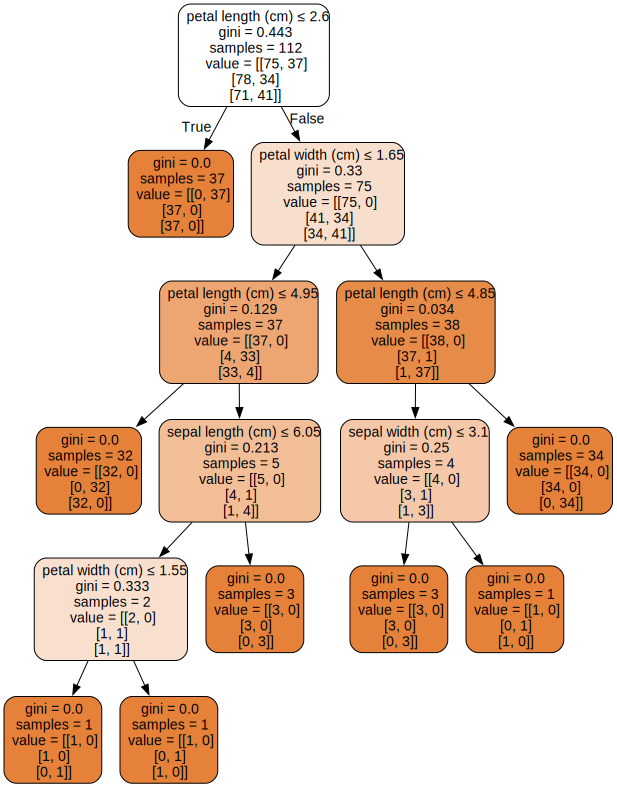

In [9]:
dot_data = tree.export_graphviz(dt,
feature_names=iris.feature_names,
class_names=iris.target_names,
filled=True, rounded=True,
special_characters=True)
graph = graphviz.Source(dot_data)
graph

In [10]:
# Menentukan hasil prediksi dari
y_pred = dt.predict(X_test)
y_pred

array([[ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [False, False,  True],
       [ True, False, False],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [False,  True, False],
       [ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [ True, False, False],
       [ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [False, False,  True],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [ True, False, False],
       [ True, False, False],
       [False,  True, False],
       [False, False,  True],
       [False,  True, False],
       [False, False,  True],
       [False,  True, False],
       [Fa

In [11]:
species = np.array(y_test).argmax(axis=1)
predictions = np.array(y_pred).argmax(axis=1)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(species, predictions))
print(classification_report(species, predictions))
print('akurasi :', accuracy_score(species, predictions))

[[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.94      0.97        16
           2       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

akurasi : 0.9736842105263158


#  Post Test

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import graphviz

In [19]:
data = pd.read_csv(r'C:\py data\marketing_campaign.csv', sep='\t')

In [20]:
print(data.shape)
print(data.columns.to_list())
data.head()

(2240, 29)
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [21]:
X = data[['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency']]
y = data['Response']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

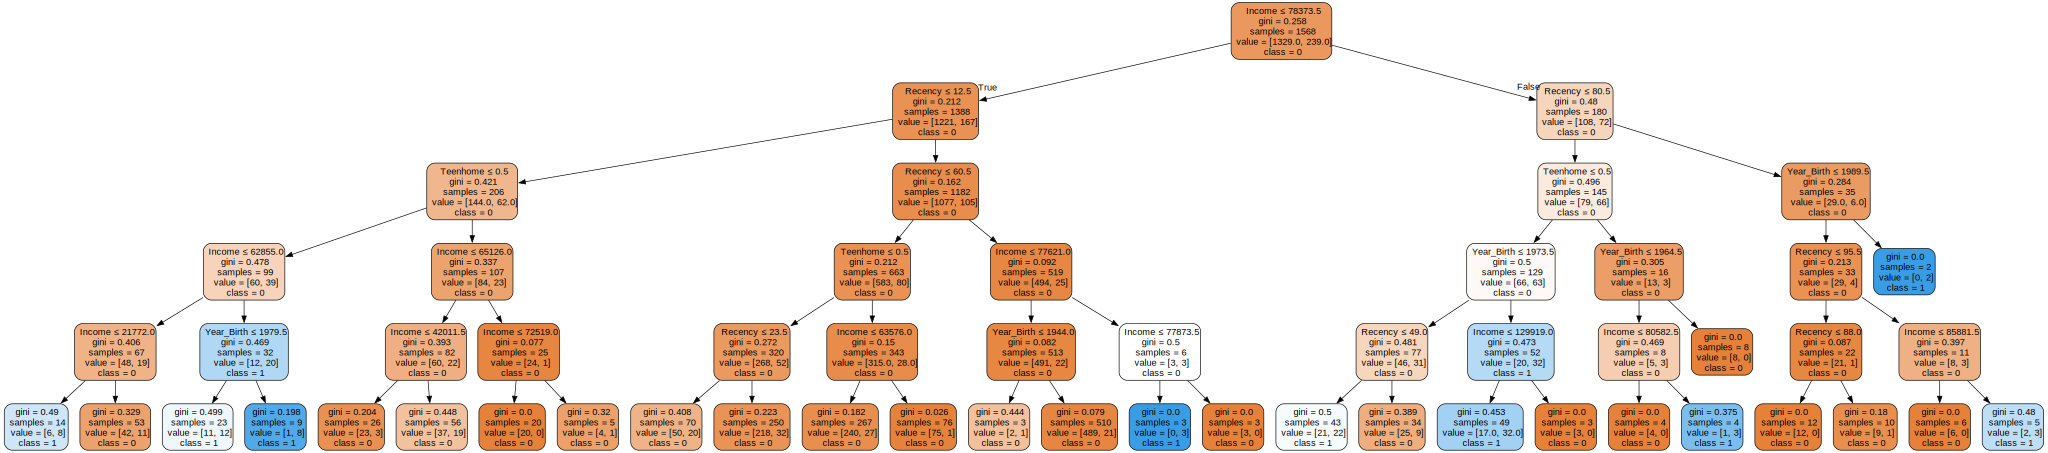

In [28]:
dot_data = tree.export_graphviz(
    model,
    feature_names=X.columns,
    class_names=["0", "1"],  # perbaikan disini
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph


In [24]:
y_pred = model.predict(X_test)

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8363095238095238
Confusion Matrix:
 [[537  40]
 [ 70  25]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.91       577
           1       0.38      0.26      0.31        95

    accuracy                           0.84       672
   macro avg       0.63      0.60      0.61       672
weighted avg       0.81      0.84      0.82       672



In [13]:
import pandas as pd
from sklearn import tree
import graphviz
import matplotlib.pyplot as plt
from sklearn import datasets
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier

In [14]:
data_wine = pd.read_csv(r'C:\Py Data\winequality-red.csv')

In [15]:
data_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [16]:
X = data_wine.drop('quality', axis=1)
y = data_wine['quality']

In [17]:
y = pd.get_dummies(y)

In [18]:
y

,3,4,5,6,7,8
0,False,False,True,False,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,False,True,False,False
4,False,False,True,False,False,False
...,...,...,...,...,...,...
1594,False,False,True,False,False,False
1595,False,False,False,True,False,False
1596,False,False,False,True,False,False
1597,False,False,True,False,False,False


In [19]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [20]:
x_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [21]:
data_wine = DecisionTreeClassifier()
data_wine.fit(x_train, y_train)

DecisionTreeClassifier()

In [29]:
from sklearn import tree

dot_data = tree.export_graphviz(
    data_wine,
    feature_names=X.columns,
    class_names=[str(c) for c in y.iloc[:, 0].unique()],
    filled=True,
    rounded=True,
    special_characters=True
)


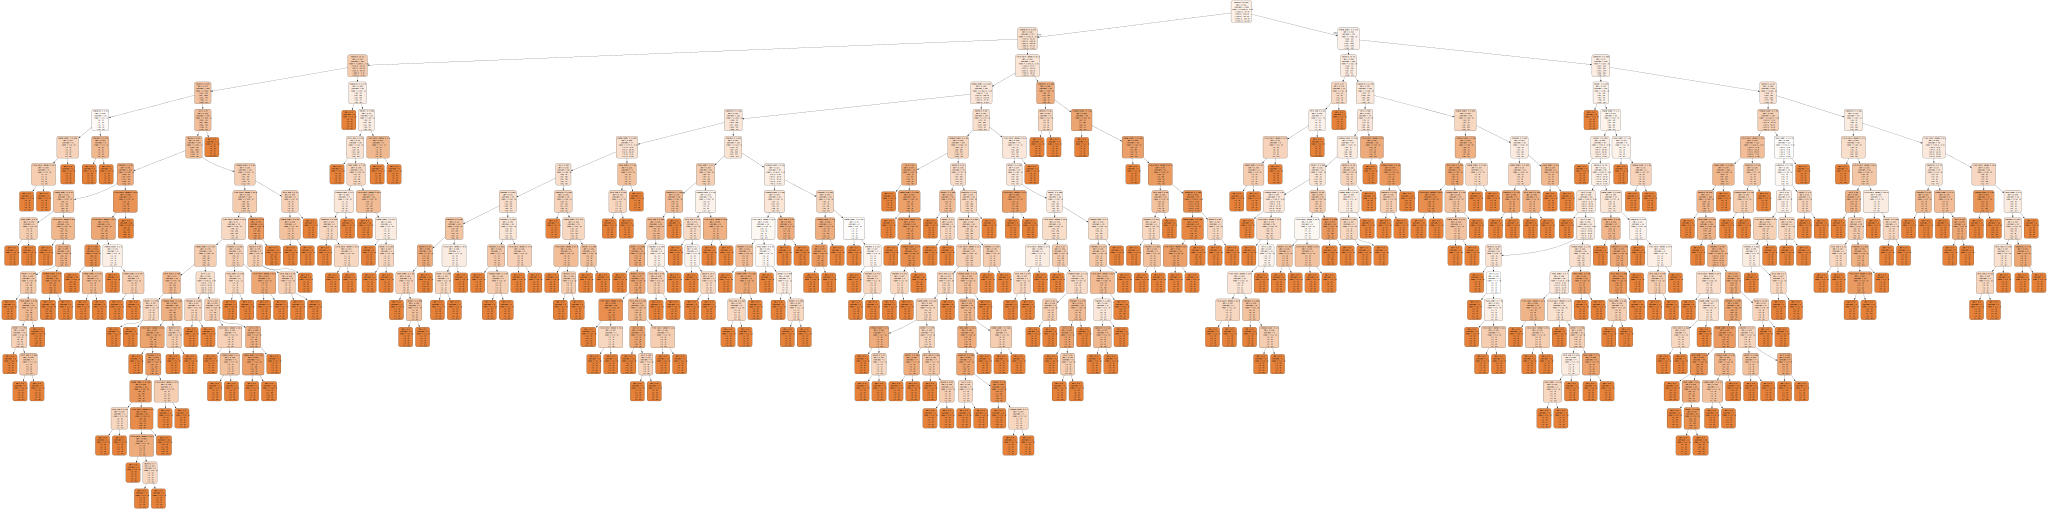

In [30]:
graph = graphviz.Source(dot_data)
graph

In [46]:
y_pred = data_wine.predict(X_test)

In [48]:
species = np.array(y_test)  # langsung 1D array
predictions = np.array(y_pred)

In [49]:
print("y_test shape:", np.array(y_test).shape)
print("y_pred shape:", np.array(y_pred).shape)

print("contoh y_test:", np.array(y_test)[:10])
print("contoh y_pred:", np.array(y_pred)[:10])


y_test shape: (400,)
y_pred shape: (400, 6)
contoh y_test: [False False False False False False False False False False]
contoh y_pred: [[False False  True False False False]
 [False False  True False False False]
 [False False False  True False False]
 [False False False  True False False]
 [False False  True False False False]
 [False False False  True False False]
 [False False False  True False False]
 [False False  True False False False]
 [False False  True False False False]
 [False False  True False False False]]
